In [263]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

In [264]:
tickers=['JPM','MA','WMT','NFLX','ORCL','TMUS','IBM','MCD','MS','AXP']
monthly_returns=yf.download(tickers,start="2015-01-01",end="2025-01-01",interval='1mo')["Close"].pct_change()*100
monthly_returns.dropna(inplace=True)
monthly_returns.index = monthly_returns.index.strftime('%Y-%m')
monthly_returns.index = pd.to_datetime(monthly_returns.index).to_period("M")
monthly_returns=monthly_returns/100
monthly_returns

[*********************100%***********************]  10 of 10 completed


Ticker,AXP,IBM,JPM,MA,MCD,MS,NFLX,ORCL,TMUS,WMT
Date,,,,,,,,,,
2015-02,0.014129,0.056291,0.134134,0.100864,0.069883,0.061625,0.074943,0.048913,0.094433,-0.012356
2015-03,-0.042530,-0.001940,-0.011423,-0.041495,-0.006200,-0.002794,-0.122592,-0.015290,-0.040569,-0.020016
2015-04,-0.005263,0.067228,0.044239,0.044218,-0.009134,0.045391,0.335525,0.010893,0.074156,-0.045365
2015-05,0.029309,-0.009574,0.046747,0.024602,-0.006421,0.028016,0.121402,0.000514,0.142186,-0.048430
2015-06,-0.025088,-0.033947,0.030101,0.013223,-0.000353,0.015445,0.052687,-0.073350,-0.002829,-0.038943
...,...,...,...,...,...,...,...,...,...,...
2024-08,0.025215,0.051993,0.062245,0.043876,0.087641,0.012906,0.116177,0.016055,0.090191,0.125146
2024-09,0.048521,0.103318,-0.062011,0.021641,0.054909,0.006080,0.011293,0.206030,0.041831,0.048559
2024-10,-0.004130,-0.064954,0.052452,0.011725,-0.035139,0.115215,0.065927,-0.015023,0.081411,0.014861


In [265]:
ff_factors=pd.read_csv("F-F_Research_Data_Factors.csv",index_col=0)
ff_factors.index.names=["Date"]
ff_factors.index=pd.to_datetime(ff_factors.index,format="%Y%m")
ff_factors.index=ff_factors.index.to_period("M")
ff_factors=ff_factors/100
ff_factors

,Mkt-RF,SMB,HML,RF
Date,,,,
1926-07,0.0296,-0.0256,-0.0243,0.0022
1926-08,0.0264,-0.0117,0.0382,0.0025
1926-09,0.0036,-0.0140,0.0013,0.0023
1926-10,-0.0324,-0.0009,0.0070,0.0032
1926-11,0.0253,-0.0010,-0.0051,0.0031
...,...,...,...,...
2024-03,0.0283,-0.0251,0.0421,0.0043
2024-04,-0.0467,-0.0239,-0.0052,0.0047
2024-05,0.0434,0.0078,-0.0166,0.0044


In [266]:
#matching index of ff_factors with monthly_returns
ff_factors_subset=ff_factors[ff_factors.index.isin(monthly_returns.index)].copy()
#concatenating both ff_factors and monthly_returns
ff_factors_subset=pd.concat([ff_factors_subset,monthly_returns],axis=1)
ff_factors_subset.dropna(inplace=True)
ff_factors_subset

,Mkt-RF,SMB,HML,RF,AXP,IBM,JPM,MA,MCD,MS,NFLX,ORCL,TMUS,WMT
Date,,,,,,,,,,,,,,
2015-02,0.0613,0.0063,-0.0186,0.0000,0.014129,0.056291,0.134134,0.100864,0.069883,0.061625,0.074943,0.048913,0.094433,-0.012356
2015-03,-0.0112,0.0304,-0.0038,0.0000,-0.042530,-0.001940,-0.011423,-0.041495,-0.006200,-0.002794,-0.122592,-0.015290,-0.040569,-0.020016
2015-04,0.0059,-0.0306,0.0182,0.0000,-0.005263,0.067228,0.044239,0.044218,-0.009134,0.045391,0.335525,0.010893,0.074156,-0.045365
2015-05,0.0136,0.0094,-0.0115,0.0000,0.029309,-0.009574,0.046747,0.024602,-0.006421,0.028016,0.121402,0.000514,0.142186,-0.048430
2015-06,-0.0153,0.0291,-0.0079,0.0000,-0.025088,-0.033947,0.030101,0.013223,-0.000353,0.015445,0.052687,-0.073350,-0.002829,-0.038943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03,0.0283,-0.0251,0.0421,0.0043,0.037690,0.041458,0.076535,0.014344,-0.029854,0.094375,0.007314,0.124731,0.003492,0.026616
2024-04,-0.0467,-0.0239,-0.0052,0.0047,0.027845,-0.129661,-0.042736,-0.063065,-0.031601,-0.035259,-0.093343,-0.094419,0.005820,-0.010269
2024-05,0.0434,0.0078,-0.0166,0.0044,0.028687,0.003911,0.062960,-0.007781,-0.051824,0.087012,0.165226,0.033566,0.065725,0.108003


In [267]:
import statsmodels.api as sm

In [268]:
rf=ff_factors_subset['RF']
returns=ff_factors_subset.iloc[:,4:] # Dataframe of Returns for each stock
market=ff_factors_subset['Mkt-RF'] # Market return
smb=ff_factors_subset['SMB'] # SMB factor
hml=ff_factors_subset['HML'] # HML factor

In [269]:
def fama_french_regression(returns,market,smb,hml,rf):
    X=sm.add_constant(pd.concat([market,smb,hml],axis=1))
    betas=[]
    for stock in returns.columns:
        Y=returns[stock]-rf
        model=sm.OLS(Y,X).fit()
        betas.append(model.params.values)
    betas_df=pd.DataFrame(betas,columns=['alpha','beta_mkt','beta_smb','beta_hml'],index=returns.columns)
    return betas_df,model

factors,model=fama_french_regression(returns,market,smb,hml,rf)

In [270]:
factors

,alpha,beta_mkt,beta_smb,beta_hml
AXP,0.002525,1.106261,0.165551,0.508907
IBM,-0.001423,0.858319,-0.218463,0.354909
JPM,0.005823,1.072432,0.126246,0.807738
MA,0.005450,1.090145,-0.420281,0.075363
MCD,0.004487,0.660046,-0.451230,0.193617
MS,0.002633,1.281280,0.365016,0.708539
NFLX,0.012394,1.316241,-0.051501,-0.925597
ORCL,0.001475,1.075806,-0.566883,-0.110075
TMUS,0.011418,0.494402,0.001324,0.016182
WMT,0.003866,0.507864,-0.472635,-0.154550


In [271]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.217
Model:                            OLS   Adj. R-squared:                  0.196
Method:                 Least Squares   F-statistic:                     10.19
Date:                Fri, 13 Jun 2025   Prob (F-statistic):           5.64e-06
Time:                        13:05:40   Log-Likelihood:                 188.46
No. Observations:                 114   AIC:                            -368.9
Df Residuals:                     110   BIC:                            -358.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0039      0.005      0.851      0.3

In [231]:
pip install cvxpy

Note: you may need to restart the kernel to use updated packages.


In [272]:
import cvxpy as cp

w = cp.Variable(len(tickers))
constraints = [
    cp.sum(w) == 1,
    factors['beta_hml'].values @ w == 0
]
objective = cp.Minimize(cp.sum_squares(w))
prob = cp.Problem(objective, constraints)
prob.solve()
hml_neutral_weights = w.value
print("HML-Neutral Portfolio Weights:", dict(zip(tickers, np.round(hml_neutral_weights, 4))))


HML-Neutral Portfolio Weights: {'JPM': 0.0764, 'MA': 0.0865, 'WMT': 0.0569, 'NFLX': 0.1047, 'ORCL': 0.097, 'TMUS': 0.0634, 'IBM': 0.1701, 'MCD': 0.1168, 'MS': 0.1086, 'AXP': 0.1197}


Traditional MVO Model

In [273]:
mean_returns=monthly_returns.mean()
annualized_mean_returns=(mean_returns)* 12 
annualized_mean_returns = annualized_mean_returns.squeeze()

In [274]:
cov_matrix = monthly_returns.cov()

In [275]:
annualised_cov_matrix=cov_matrix*12

In [276]:
annualised_cov_matrix

Ticker,AXP,IBM,JPM,MA,MCD,MS,NFLX,ORCL,TMUS,WMT
Ticker,,,,,,,,,,
AXP,0.067067,0.027971,0.043576,0.040394,0.017307,0.053807,0.029726,0.026422,0.019200,0.009982
IBM,0.027971,0.055108,0.025896,0.027864,0.015981,0.025932,0.022098,0.029412,0.015622,0.010163
JPM,0.043576,0.025896,0.059494,0.028759,0.014597,0.058506,0.034777,0.026275,0.016589,0.008049
MA,0.040394,0.027864,0.028759,0.051133,0.021032,0.036119,0.036125,0.024690,0.017268,0.009126
MCD,0.017307,0.015981,0.014597,0.021032,0.029561,0.013870,0.005605,0.017717,0.008843,0.010601
MS,0.053807,0.025932,0.058506,0.036119,0.013870,0.084854,0.033910,0.026746,0.019620,0.009488
NFLX,0.029726,0.022098,0.034777,0.036125,0.005605,0.033910,0.171455,0.042316,0.021879,0.009873
ORCL,0.026422,0.029412,0.026275,0.024690,0.017717,0.026746,0.042316,0.061365,0.009154,0.015046
TMUS,0.019200,0.015622,0.016589,0.017268,0.008843,0.019620,0.021879,0.009154,0.042247,0.010653


In [151]:
pip install PyPortfolioOpt

Note: you may need to restart the kernel to use updated packages.


Max Sharpe Portfolio: OrderedDict({'AXP': 0.0, 'IBM': 0.0, 'JPM': 0.07124, 'MA': 0.05283, 'MCD': 0.255, 'MS': 0.0, 'NFLX': 0.1197, 'ORCL': 0.0, 'TMUS': 0.30294, 'WMT': 0.19829})
Expected annual return: 20.8%
Annual volatility: 14.2%
Sharpe Ratio: 1.46


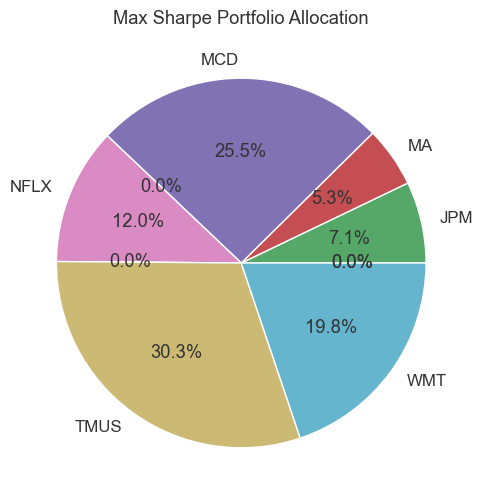

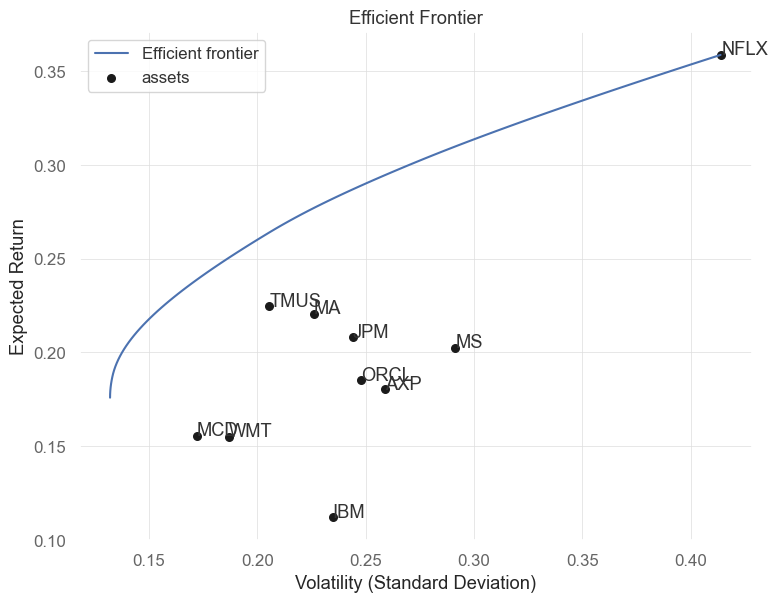

In [277]:
def MVO(returns,cov_matrix):
    from pypfopt import EfficientFrontier, risk_models, expected_returns
    from pypfopt.plotting import plot_efficient_frontier
    
    ef = EfficientFrontier(returns,cov_matrix)

    sharpe_weights = ef.max_sharpe()
    cleaned_weights = ef.clean_weights()
    print("Max Sharpe Portfolio:", cleaned_weights)
    print("="*60)
    performance = ef.portfolio_performance(verbose=True)
    print("="*60)

    cleaned_weights = ef.clean_weights()
    
    #plotting bar graph to show weights
    weights_series = pd.Series(cleaned_weights)
    weights_series.plot.pie(autopct='%1.1f%%')
    plt.title("Max Sharpe Portfolio Allocation")
    plt.ylabel("")
    plt.show()

    #plotting efficient frontier
    ef_plot = EfficientFrontier(returns, cov_matrix,solver="SCS")

    fig, ax = plt.subplots(figsize=(8, 6))
    plot_efficient_frontier(ef_plot, ax=ax, show_assets=True,show_tickers=True)

    plt.title("Efficient Frontier")
    plt.xlabel("Volatility (Standard Deviation)")
    plt.ylabel("Expected Return")
    plt.grid(True)
    plt.legend()
    plt.show()

    return cleaned_weights

cleaned_trad_weights=MVO(annualized_mean_returns,annualised_cov_matrix)   
    

Factor_Based MVO Model

In [278]:
expected_returns=[]
for i in monthly_returns:
    expected_return=factors.loc[i,"alpha"]+ factors.loc[i,"beta_mkt"]*market.mean()+factors.loc[i,"beta_smb"]*smb.mean() + factors.loc[i,"beta_hml"]*hml.mean()
    expected_returns.append(expected_return*12)
expected_returns


[0.1544637577007975,
 0.0841394251241029,
 0.18651495724086756,
 0.20072469804202137,
 0.13628375175650384,
 0.1716591106552243,
 0.3198588804550433,
 0.15559885666700543,
 0.1962151692783458,
 0.11541501287192318]

Max Sharpe Portfolio: OrderedDict({'AXP': 0.0, 'IBM': 0.0, 'JPM': 0.07712, 'MA': 0.07702, 'MCD': 0.27374, 'MS': 0.0, 'NFLX': 0.12623, 'ORCL': 0.0, 'TMUS': 0.319, 'WMT': 0.12689})
Expected annual return: 18.5%
Annual volatility: 14.6%
Sharpe Ratio: 1.27


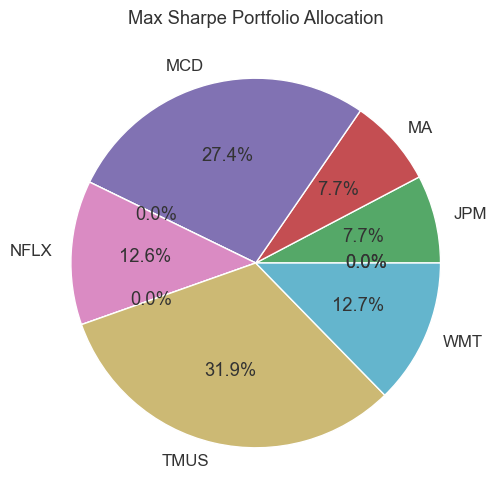

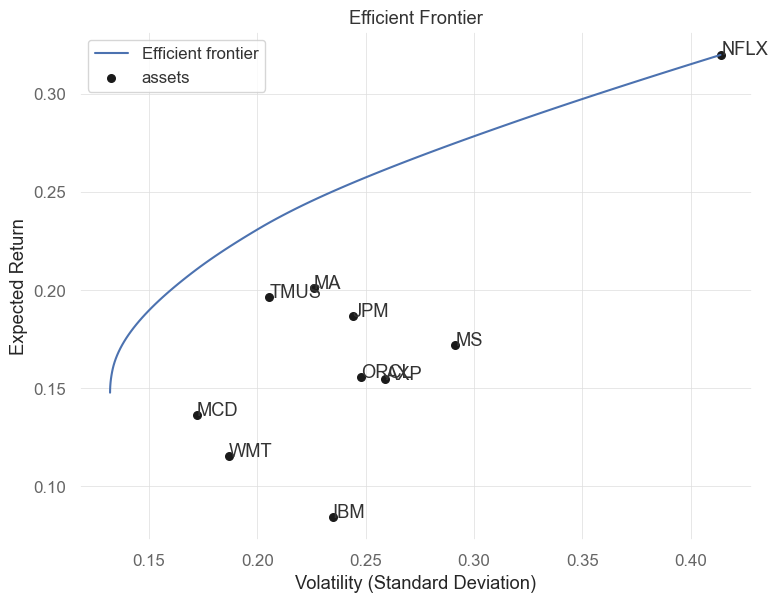

In [279]:
cleaned_factor_weights=MVO(expected_returns,annualised_cov_matrix)

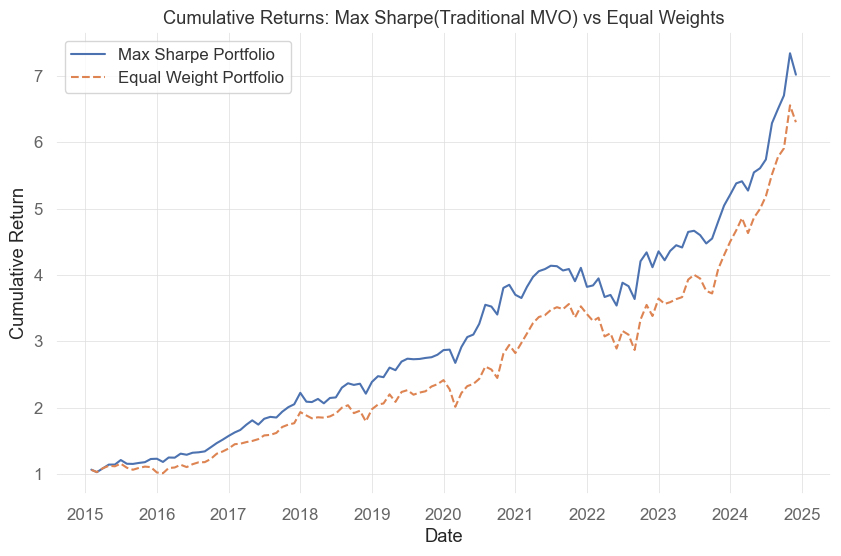

In [280]:
weights_series = pd.Series(cleaned_trad_weights)
weights_series = weights_series.reindex(monthly_returns.columns)

portfolio_returns = (monthly_returns * weights_series).sum(axis=1)

equal_weights = np.repeat(1/len(monthly_returns.columns), len(monthly_returns.columns))
equal_weight_returns = (monthly_returns * equal_weights).sum(axis=1)

cumulative_returns_portfolio = (1 + portfolio_returns).cumprod()
cumulative_returns_equal = (1 + equal_weight_returns).cumprod()

cumulative_returns_portfolio.index = cumulative_returns_portfolio.index.to_timestamp()
cumulative_returns_equal.index = cumulative_returns_equal.index.to_timestamp()


# Plotting
plt.figure(figsize=(10, 6))
plt.plot(cumulative_returns_portfolio, label="Max Sharpe Portfolio")
plt.plot(cumulative_returns_equal, label="Equal Weight Portfolio", linestyle="--")
plt.title("Cumulative Returns: Max Sharpe(Traditional MVO) vs Equal Weights")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
#plt.tight_layout()
plt.show()


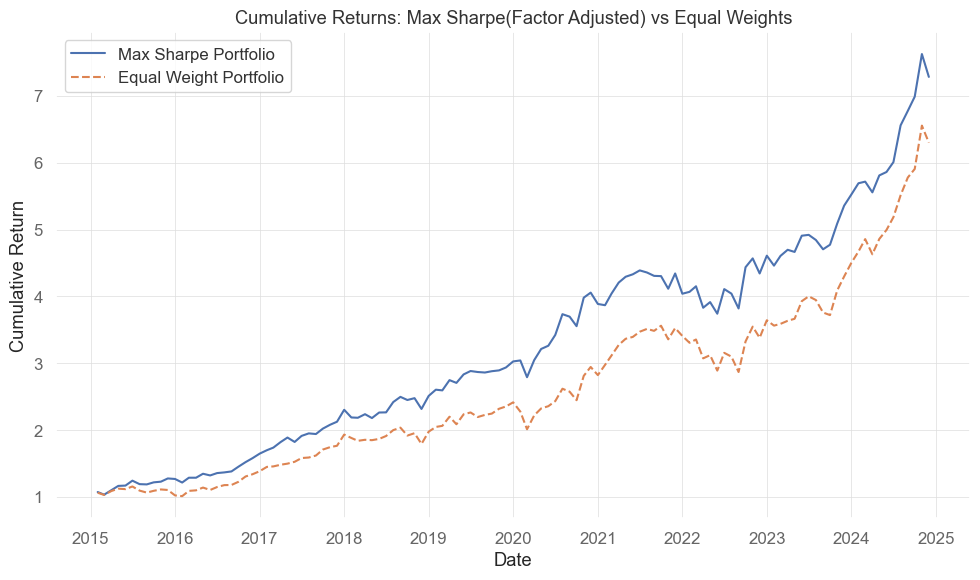

In [281]:
weights_series = pd.Series(cleaned_factor_weights)
weights_series = weights_series.reindex(monthly_returns.columns)

portfolio_returns = (monthly_returns * weights_series).sum(axis=1)

equal_weights = np.repeat(1/len(monthly_returns.columns), len(monthly_returns.columns))
equal_weight_returns = (monthly_returns * equal_weights).sum(axis=1)

cumulative_returns_portfolio = (1 + portfolio_returns).cumprod()
cumulative_returns_equal = (1 + equal_weight_returns).cumprod()

cumulative_returns_portfolio.index = cumulative_returns_portfolio.index.to_timestamp()
cumulative_returns_equal.index = cumulative_returns_equal.index.to_timestamp()

#plotting
plt.figure(figsize=(10, 6))
plt.plot(cumulative_returns_portfolio, label="Max Sharpe Portfolio")
plt.plot(cumulative_returns_equal, label="Equal Weight Portfolio", linestyle="--")
plt.title("Cumulative Returns: Max Sharpe(Factor Adjusted) vs Equal Weights")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
